# Longitudinal22 held-out validation: 4 patients

Evaluation-only notebook for the patient-level 18/4 split. It never trains and never reads the 101-pair test set.


In [1]:
import os
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Sequential
import torch.optim as optim
import voxelmorph as vxm
import neurite as ne
import scipy.ndimage

os.environ['VXM_BACKEND'] = 'pytorch'

backend:pytorch
Pytorch


In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [3]:
# configure unet input shape (concatenation of moving and fixed images)
ndim = 3
unet_input_features = 2
# inshape = (*x_train.shape[1:], unet_input_features)

nb_features = [
    [32, 64, 64, 64, 64],
    [64, 64, 64, 64, 64, 32, 16, 16]
]


In [4]:
import math
from pathlib import Path

import torch
import matplotlib.pyplot as plt

band_names = ['LLL', 'LLH', 'LHL', 'LHH', 'HLL', 'HLH', 'HHL', 'HHH']
wavelet_vis_enabled = False
wavelet_vis_every = 100
wavelet_vis_dir = Path('wavelet_stage_outputs')
wavelet_vis_dir.mkdir(exist_ok=True)

class Haar3DAnalysisOnly(nn.Module):
    def __init__(self):
        super().__init__()

        hL = torch.tensor([1.0, 1.0], dtype=torch.float32) / math.sqrt(2.0)
        hH = torch.tensor([1.0, -1.0], dtype=torch.float32) / math.sqrt(2.0)

        filters = []
        names = []

        for z_name, z_filter in zip(['L', 'H'], [hL, hH]):
            for y_name, y_filter in zip(['L', 'H'], [hL, hH]):
                for x_name, x_filter in zip(['L', 'H'], [hL, hH]):
                    kernel = (
                        z_filter[:, None, None]
                        * y_filter[None, :, None]
                        * x_filter[None, None, :]
                    )
                    filters.append(kernel)
                    names.append(z_name + y_name + x_name)

        weight = torch.stack(filters, dim=0).unsqueeze(1)
        self.register_buffer('weight', weight)
        self.names = names

    def forward(self, x):
        x = F.pad(x, (0, 1, 0, 1, 0, 1))
        return F.conv3d(x, self.weight, stride=1, padding=0)

def analysis_filter_3d(x, analysis_layer):
    return analysis_layer(x)

def down_sampling_3d(w):
    return w[:, :, ::2, ::2, ::2]

def up_sampling_3d(w_down):
    B, C, D, H, W = w_down.shape
    w_up = torch.zeros(
        B, C, D * 2, H * 2, W * 2,
        dtype=w_down.dtype,
        device=w_down.device
    )
    w_up[:, :, ::2, ::2, ::2] = w_down
    return w_up

def make_3d_filter(fz, fy, fx):
    return fz[:, None, None] * fy[None, :, None] * fx[None, None, :]

def create_synthesis_filters(device):
    low = torch.tensor([1.0, 1.0], dtype=torch.float32, device=device) / math.sqrt(2.0)
    high = torch.tensor([1.0, -1.0], dtype=torch.float32, device=device) / math.sqrt(2.0)

    filters = torch.stack([
        make_3d_filter(low, low, low),
        make_3d_filter(low, low, high),
        make_3d_filter(low, high, low),
        make_3d_filter(low, high, high),
        make_3d_filter(high, low, low),
        make_3d_filter(high, low, high),
        make_3d_filter(high, high, low),
        make_3d_filter(high, high, high),
    ], dim=0)

    filters = torch.flip(filters, dims=[1, 2, 3]).unsqueeze(1)
    return filters

def synthesis_filter_3d(w_up, synthesis_filters):
    B, C, D, H, W = w_up.shape
    filtered_bands = []

    for i in range(C):
        band = w_up[:, i:i + 1, :, :, :]
        kernel = synthesis_filters[i:i + 1]
        filtered = F.conv3d(band, kernel, stride=1, padding=1)
        filtered = filtered[:, :, :D, :H, :W]
        filtered_bands.append(filtered)

    filtered_bands = torch.cat(filtered_bands, dim=1)
    reconstructed = torch.sum(filtered_bands, dim=1, keepdim=True)
    return reconstructed, filtered_bands

def _resolve_slice_index(volume, slice_index=None):
    depth = volume.shape[2]
    if slice_index is None:
        return depth // 2
    return min(slice_index, depth - 1)

def _band_to_image(volume, band_index, slice_index=None):
    z_index = _resolve_slice_index(volume, slice_index)
    image = volume[0, band_index, z_index].detach().cpu().numpy()
    return image

def plot_wavelet_band_grid(volume, title_prefix, save_path=None, slice_index=None):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for band_index, band_name in enumerate(band_names):
        image = _band_to_image(volume, band_index, slice_index=slice_index)
        axes[band_index].imshow(image, cmap='gray')
        axes[band_index].set_title(f'{band_name} {title_prefix}')
        axes[band_index].axis('off')

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)


def plot_original_image_triplet(moving_image, fixed_image, warped_image, save_path=None, slice_index=64):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(moving_image[0, 0, slice_index].detach().cpu(), cmap='gray')
    axes[0].set_title('Moving')
    axes[0].axis('off')

    axes[1].imshow(fixed_image[0, 0, slice_index].detach().cpu(), cmap='gray')
    axes[1].set_title('Fixed')
    axes[1].axis('off')

    axes[2].imshow(warped_image[0, 0, slice_index].detach().cpu(), cmap='gray')
    axes[2].set_title('Warped')
    axes[2].axis('off')

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)


def plot_single_original_image(image, title='Original Image', save_path=None, slice_index=64):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(image[0, 0, slice_index].detach().cpu(), cmap='gray')
    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)

def visualize_wavelet_stages(
    analysis_bands=None,
    downsampled_bands=None,
    upsampled_bands=None,
    synthesis_bands=None,
    epoch=None,
    prefix='train'
):
    output_dir = wavelet_vis_dir / prefix
    output_dir.mkdir(parents=True, exist_ok=True)
    epoch_tag = f'epoch_{epoch:05d}' if epoch is not None else 'latest'

    if analysis_bands is not None:
        plot_wavelet_band_grid(
            analysis_bands,
            'analysis',
            save_path=output_dir / f'{epoch_tag}_analysis_8bands.png'
        )

    if downsampled_bands is not None:
        plot_wavelet_band_grid(
            downsampled_bands,
            'downsampled',
            save_path=output_dir / f'{epoch_tag}_downsampled_8bands.png'
        )

    if upsampled_bands is not None:
        plot_wavelet_band_grid(
            upsampled_bands,
            'upsampled',
            save_path=output_dir / f'{epoch_tag}_upsampled_8bands.png'
        )

    if synthesis_bands is not None:
        plot_wavelet_band_grid(
            synthesis_bands,
            'synthesis',
            save_path=output_dir / f'{epoch_tag}_synthesis_8bands.png'
        )

analysis = Haar3DAnalysisOnly().to(device)
synthesis_filters = create_synthesis_filters(device)
analysis_names = analysis.names

In [5]:
# Longitudinal22 patient-level 18-train / 4-validation setup.
from pathlib import Path
import csv
import random
import re
import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import voxelmorph as vxm

DATA_ROOT = Path('Data/Longitudinal22')
TEST_ROOT = Path('Data/TestData')
PRETRAINED_PATH = Path('model_analysis_pipeline_pretrain.pth')
CHECKPOINT_DIR = Path('longitudinal22_18train_4val_checkpoints')
BEST_PATH = CHECKPOINT_DIR / 'model_analysis_pipeline_longitudinal22_18train_4val_best.pth'
SPLIT_SEED = 20260725
VALIDATION_COUNT = 4

pair_dirs = sorted([path for path in DATA_ROOT.glob('pair*') if path.is_dir()], key=lambda path: int(re.search(r'\d+', path.name).group()))
if len(pair_dirs) != 22:
    raise ValueError(f'Expected 22 longitudinal pairs, found {len(pair_dirs)} in {DATA_ROOT.resolve()}')

def patient_id(path):
    match = re.search(r'MIC\d+', path.name, flags=re.I)
    if match is None:
        raise ValueError(f'Patient ID was not found in {path}')
    return match.group(0).upper()

def load_volume(path):
    with np.load(path, allow_pickle=False) as archive:
        volume = np.asarray(archive['Train'], dtype=np.float32)
    if volume.shape != (128, 256, 256):
        raise ValueError(f'Unexpected volume shape {volume.shape}: {path}')
    return volume

pairs = []
for pair_dir in pair_dirs:
    moving_paths = list(pair_dir.glob('registered_masked_A_*.npz'))
    fixed_paths = list(pair_dir.glob('fixed_masked_B_*.npz'))
    if len(moving_paths) != 1 or len(fixed_paths) != 1:
        raise ValueError(f'{pair_dir}: expected exactly one moving and fixed NPZ')
    if patient_id(moving_paths[0]) != patient_id(fixed_paths[0]):
        raise ValueError(f'{pair_dir}: moving/fixed patient mismatch')
    pairs.append((pair_dir.name, patient_id(moving_paths[0]), moving_paths[0], fixed_paths[0]))
if len({record[1] for record in pairs}) != len(pairs):
    raise ValueError('The 22-pair protocol requires one pair per patient.')
if TEST_ROOT.exists():
    test_patient_ids = set()
    for test_dir in TEST_ROOT.glob('pair*'):
        for test_path in list(test_dir.glob('registered_masked_A_*.npz')) + list(test_dir.glob('fixed_masked_B_*.npz')):
            test_patient_ids.add(patient_id(test_path))
    overlap_with_test = {record[1] for record in pairs} & test_patient_ids
    if overlap_with_test:
        raise ValueError(f'Longitudinal22/TestData patient overlap: {sorted(overlap_with_test)}')
    print(f'TestData overlap check: 0 shared patients ({len(test_patient_ids)} test patients)')
else:
    print('WARNING: Data/TestData was not found; test-patient overlap could not be checked.')

split_rng = random.Random(SPLIT_SEED)
split_rng.shuffle(pairs)
validation_pairs = sorted(pairs[:VALIDATION_COUNT])
train_pairs = sorted(pairs[VALIDATION_COUNT:])
train_ids, validation_ids = {record[1] for record in train_pairs}, {record[1] for record in validation_pairs}
if train_ids & validation_ids:
    raise AssertionError('Patient leakage between train and validation sets')
print(f'Train: {len(train_pairs)} pairs / {sorted(train_ids)}')
print(f'Validation: {len(validation_pairs)} pairs / {sorted(validation_ids)}')

model3D = vxm.networks.VxmDense_128_256_256((128, 256, 256), nb_features, int_steps=0).to(device)
transformer = vxm.layers.SpatialTransformer((64, 128, 128)).to(device)

def reconstruct_warped(moving, fixed):
    moving_bands = down_sampling_3d(analysis_filter_3d(moving, analysis))
    fixed_bands = down_sampling_3d(analysis_filter_3d(fixed, analysis))
    flow = model3D(moving_bands, fixed_bands)
    warped_bands = torch.cat([transformer(moving_bands[:, i:i + 1], flow) for i in range(8)], dim=1)
    warped, _ = synthesis_filter_3d(up_sampling_3d(warped_bands), synthesis_filters)
    return warped, flow

def mse(target, prediction):
    return (target - prediction).square().mean()

def mae(target, prediction):
    return (target - prediction).abs().mean()

def ncc(target, prediction, eps=1e-6):
    target = target - target.mean()
    prediction = prediction - prediction.mean()
    return (target * prediction).sum() / torch.sqrt(target.square().sum() * prediction.square().sum()).clamp_min(eps)

def evaluate_pairs(records):
    values, representative = [], None
    model3D.eval()
    with torch.no_grad():
        for pair_name, patient, moving_path, fixed_path in records:
            moving = torch.from_numpy(load_volume(moving_path)).unsqueeze(0).unsqueeze(0).to(device)
            fixed = torch.from_numpy(load_volume(fixed_path)).unsqueeze(0).unsqueeze(0).to(device)
            warped, flow = reconstruct_warped(moving, fixed)
            values.append({'pair': pair_name, 'patient_id': patient, 'mse_before': mse(fixed, moving).item(), 'mse_after': mse(fixed, warped).item(), 'mae_before': mae(fixed, moving).item(), 'mae_after': mae(fixed, warped).item(), 'ncc_before': ncc(fixed, moving).item(), 'ncc_after': ncc(fixed, warped).item(), 'flow_abs_mean': flow.abs().mean().item()})
            if representative is None:
                representative = (moving[0, 0].cpu().numpy(), fixed[0, 0].cpu().numpy(), warped[0, 0].cpu().numpy())
    return values, representative


TestData overlap check: 0 shared patients (45 test patients)
Train: 18 pairs / ['MIC00734', 'MIC05658', 'MIC08741', 'MIC15501', 'MIC16441', 'MIC26945', 'MIC28418', 'MIC36084', 'MIC41502', 'MIC42023', 'MIC43331', 'MIC44723', 'MIC47642', 'MIC49613', 'MIC51596', 'MIC51775', 'MIC51927', 'MIC52281']
Validation: 4 pairs / ['MIC10406', 'MIC19606', 'MIC24729', 'MIC30567']
[64, 128, 128]


c:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


## Evaluate the selected best checkpoint


Validation patient IDs: ['MIC10406', 'MIC19606', 'MIC24729', 'MIC30567']
Mean metrics: {'mse_before': 0.014285511802881956, 'mse_after': 0.0017272518889512867, 'mae_before': 0.039613425731658936, 'mae_after': 0.015300747472792864, 'ncc_before': 0.8880906254053116, 'ncc_after': 0.9865391552448273, 'flow_abs_mean': 0.35484225302934647}


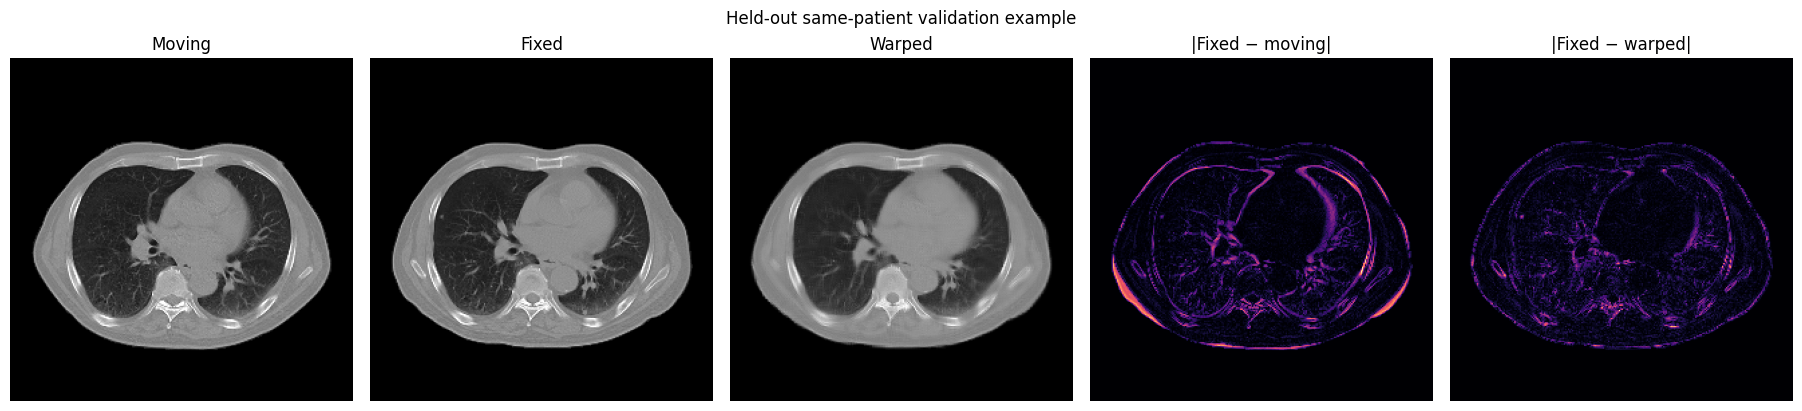

Saved: D:\Saito\longitudinal22_18train_4val_validation_results


In [6]:
# Evaluate only the four held-out validation patients using the best selected checkpoint.
if not BEST_PATH.exists():
    raise FileNotFoundError(f'Best validation checkpoint not found: {BEST_PATH.resolve()}')
try:
    checkpoint = torch.load(BEST_PATH, map_location=device, weights_only=True)
except TypeError:
    checkpoint = torch.load(BEST_PATH, map_location=device)
model3D.load_state_dict(checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint)
values, (moving, fixed, warped) = evaluate_pairs(validation_pairs)
output_dir = Path('longitudinal22_18train_4val_validation_results')
output_dir.mkdir(exist_ok=True)
with open(output_dir / 'validation_pair_metrics.csv', 'w', newline='', encoding='utf-8') as handle:
    writer = csv.DictWriter(handle, fieldnames=values[0].keys())
    writer.writeheader(); writer.writerows(values)
summary = {key: float(np.mean([value[key] for value in values])) for key in values[0] if key not in ('pair', 'patient_id')}
print('Validation patient IDs:', sorted(validation_ids))
print('Mean metrics:', summary)
center = moving.shape[0] // 2
before, after = np.abs(fixed - moving), np.abs(fixed - warped)
fig, axes = plt.subplots(1, 5, figsize=(18, 4), constrained_layout=True)
for ax, title, image, cmap in zip(axes, ['Moving', 'Fixed', 'Warped', '|Fixed − moving|', '|Fixed − warped|'], [moving[center], fixed[center], warped[center], before[center], after[center]], ['gray', 'gray', 'gray', 'magma', 'magma']):
    ax.imshow(image, cmap=cmap); ax.set_title(title); ax.axis('off')
fig.suptitle('Held-out same-patient validation example')
fig.savefig(output_dir / 'validation_representative_pair.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', output_dir.resolve())
